# Tenure Analysis — HRDataset_v14

**Goal:** Understand how long employees stay, which groups have shorter tenures, when attrition risk peaks, and what factors correlate with longer service.

**Sections:**
1. Setup & Data Loading
2. Tenure Feature Engineering
3. Overall Tenure Distribution
4. Tenure by Department
5. Active vs Terminated Tenure
6. Tenure Bins & Attrition Risk by Stage
7. Tenure by Performance Score
8. Tenure by Recruitment Source
9. Tenure by Demographics
10. Correlation: Tenure vs Key Variables
11. Survival Curve (Kaplan-Meier style)
12. Key Takeaways

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Styling ──────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (10, 5),
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = {
    'primary':  '#185FA5',
    'active':   '#0F6E56',
    'termed':   '#A32D2D',
    'neutral':  '#888780',
    'warning':  '#BA7517',
    'light':    '#E6F1FB',
}

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('data/HRDataset_v14.csv')

# Fix trailing whitespace in Department
df['Department'] = df['Department'].str.strip()

print(f'Loaded {len(df)} rows, {df.shape[1]} columns')
df.head(3)

Loaded 311 rows, 36 columns


,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3


## 2. Tenure Feature Engineering

For **active employees** we calculate tenure up to a reference date (last known data point in the dataset).  
For **terminated employees** we calculate the exact service length from hire to termination date.

In [3]:
# ── Parse dates ───────────────────────────────────────────────────────────────
df['DateofHire']        = pd.to_datetime(df['DateofHire'],        errors='coerce')
df['DateofTermination'] = pd.to_datetime(df['DateofTermination'], errors='coerce')

# Reference date = approximate end of the dataset window
REFERENCE_DATE = pd.Timestamp('2018-12-31')

# ── Calculate tenure ──────────────────────────────────────────────────────────
def calc_tenure(row):
    end = row['DateofTermination'] if pd.notna(row['DateofTermination']) else REFERENCE_DATE
    return (end - row['DateofHire']).days / 30.4375  # average days per month

df['TenureMonths'] = df.apply(calc_tenure, axis=1).round(1)
df['TenureYears']  = (df['TenureMonths'] / 12).round(2)

# ── Tenure bins ───────────────────────────────────────────────────────────────
bins   = [0, 1, 2, 3, 5, 10, 50]
labels = ['< 1 yr', '1–2 yrs', '2–3 yrs', '3–5 yrs', '5–10 yrs', '10+ yrs']
df['TenureBin'] = pd.cut(df['TenureYears'], bins=bins, labels=labels)

# ── Hire / term year ─────────────────────────────────────────────────────────
df['HireYear'] = df['DateofHire'].dt.year
df['TermYear'] = df['DateofTermination'].dt.year

print('Tenure features created.')
df[['Employee_Name','DateofHire','DateofTermination','TenureMonths','TenureYears','TenureBin']].head(8)

Tenure features created.


,Employee_Name,DateofHire,DateofTermination,TenureMonths,TenureYears,TenureBin
0,"Adinolfi, Wilson K",2011-07-05,NaT,89.9,7.49,5–10 yrs
1,"Ait Sidi, Karthikeyan",2015-03-30,2016-06-16,14.6,1.22,1–2 yrs
2,"Akinkuolie, Sarah",2011-07-05,2012-09-24,14.7,1.22,1–2 yrs
3,"Alagbe,Trina",2008-01-07,NaT,131.8,10.98,10+ yrs
4,"Anderson, Carol",2011-07-11,2016-09-06,61.9,5.16,5–10 yrs
5,"Anderson, Linda",2012-01-09,NaT,83.7,6.98,5–10 yrs
6,"Andreola, Colby",2014-11-10,NaT,49.7,4.14,3–5 yrs
7,"Athwal, Sam",2013-09-30,NaT,63.0,5.25,5–10 yrs


## 3. Overall Tenure Distribution

In [4]:
# ── Summary stats ─────────────────────────────────────────────────────────────
print('=== Tenure Summary (Years) ===')
print(df['TenureYears'].describe().round(2).to_string())
print(f"\nMedian tenure: {df['TenureYears'].median():.2f} years")
print(f"Employees with < 2 yrs tenure: {(df['TenureYears'] < 2).sum()} "
      f"({(df['TenureYears'] < 2).mean()*100:.1f}%)")

=== Tenure Summary (Years) ===
count    311.00
mean       4.72
std        2.16
min        0.08
25%        3.58
50%        4.61
75%        6.15
max       12.98

Median tenure: 4.61 years
Employees with < 2 yrs tenure: 35 (11.3%)


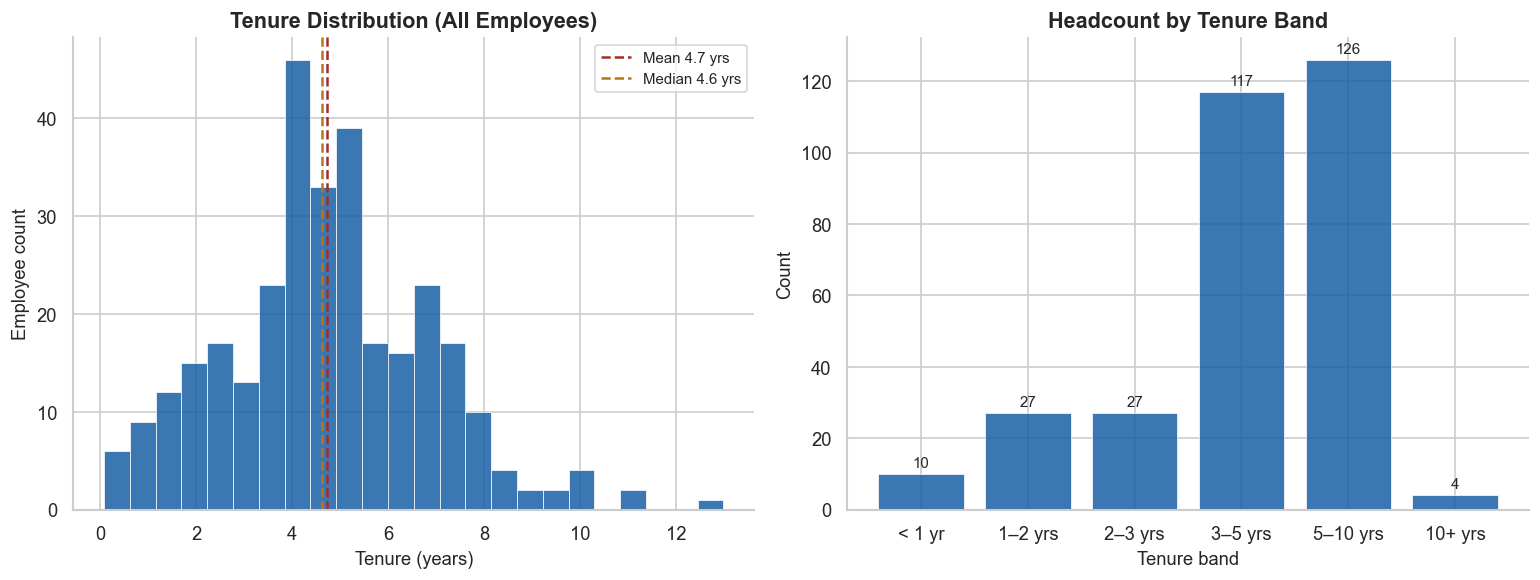

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Histogram ────────────────────────────────────────────────────────────────
ax = axes[0]
ax.hist(df['TenureYears'], bins=24, color=COLORS['primary'], alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axvline(df['TenureYears'].mean(),   color=COLORS['termed'],  linestyle='--', linewidth=1.5, label=f"Mean {df['TenureYears'].mean():.1f} yrs")
ax.axvline(df['TenureYears'].median(), color=COLORS['warning'], linestyle='--', linewidth=1.5, label=f"Median {df['TenureYears'].median():.1f} yrs")
ax.set_title('Tenure Distribution (All Employees)')
ax.set_xlabel('Tenure (years)')
ax.set_ylabel('Employee count')
ax.legend(fontsize=9)

# ── Tenure bin bar chart ───────────────────────────────────────────────────────
ax2 = axes[1]
bin_counts = df['TenureBin'].value_counts().sort_index()
bars = ax2.bar(bin_counts.index.astype(str), bin_counts.values,
               color=COLORS['primary'], alpha=0.85, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, bin_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', va='bottom', fontsize=9)
ax2.set_title('Headcount by Tenure Band')
ax2.set_xlabel('Tenure band')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

## 4. Tenure by Department

In [6]:
dept_tenure = (
    df.groupby('Department')['TenureYears']
    .agg(['mean', 'median', 'std', 'count'])
    .round(2)
    .sort_values('median', ascending=False)
    .rename(columns={'mean':'Mean (yrs)','median':'Median (yrs)','std':'Std Dev','count':'Headcount'})
)
print(dept_tenure.to_string())

                      Mean (yrs)  Median (yrs)  Std Dev  Headcount
Department                                                        
Executive Office            6.50          6.50      NaN          1
Software Engineering        4.99          5.13     1.49         11
Production                  4.85          4.87     2.08        209
Sales                       5.35          4.66     2.30         31
Admin Offices               4.68          3.88     3.37          9
IT/IS                       3.68          3.76     2.05         50


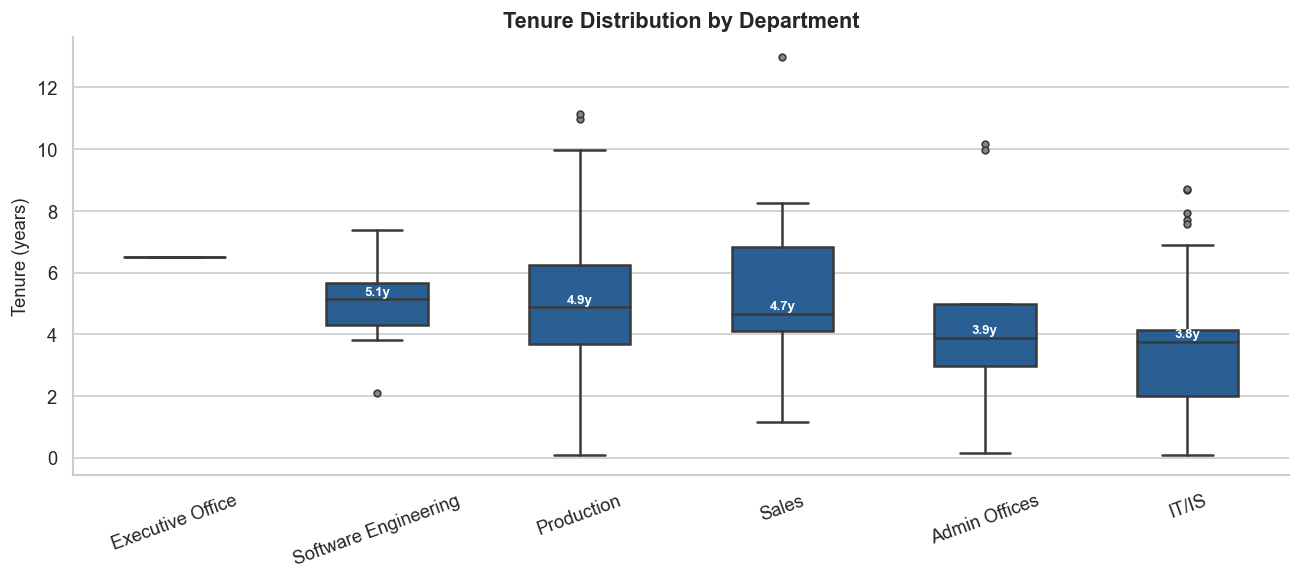

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))

dept_order = df.groupby('Department')['TenureYears'].median().sort_values(ascending=False).index

sns.boxplot(
    data=df, x='Department', y='TenureYears',
    order=dept_order,
    palette=[COLORS['primary']] * len(dept_order),
    width=0.5, flierprops=dict(marker='o', markerfacecolor=COLORS['neutral'], markersize=4),
    ax=ax
)
ax.set_title('Tenure Distribution by Department')
ax.set_xlabel('')
ax.set_ylabel('Tenure (years)')
ax.tick_params(axis='x', labelrotation=20)

# Annotate medians
for i, dept in enumerate(dept_order):
    med = df[df['Department'] == dept]['TenureYears'].median()
    ax.text(i, med + 0.15, f'{med:.1f}y', ha='center', fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
#plt.savefig('reports/figures/02_tenure_by_department.png', bbox_inches='tight')
plt.show()

## 5. Active vs Terminated Tenure

Comparing tenure for employees who left vs those still active reveals whether early exits dominate attrition.

In [9]:
active  = df[df['Termd'] == 0]['TenureYears']
termed  = df[df['Termd'] == 1]['TenureYears']

print('=== Active Employees ===')
print(active.describe().round(2).to_string())

print('\n=== Terminated Employees ===')
print(termed.describe().round(2).to_string())

# Welch's t-test (unequal variance)
t_stat, p_val = stats.ttest_ind(active, termed, equal_var=False)
print(f'\nWelch t-test: t={t_stat:.3f}, p={p_val:.4f}')
if p_val < 0.05:
    print('=> Difference in mean tenure is STATISTICALLY SIGNIFICANT (p < 0.05)')
else:
    print('=> No statistically significant difference (p >= 0.05)')

=== Active Employees ===
count    207.00
mean       5.35
std        1.95
min        0.48
25%        4.14
50%        5.13
75%        6.75
max       12.98

=== Terminated Employees ===
count    104.00
mean       3.46
std        2.02
min        0.08
25%        1.70
50%        3.40
75%        4.94
max        9.57

Welch t-test: t=7.872, p=0.0000
=> Difference in mean tenure is STATISTICALLY SIGNIFICANT (p < 0.05)


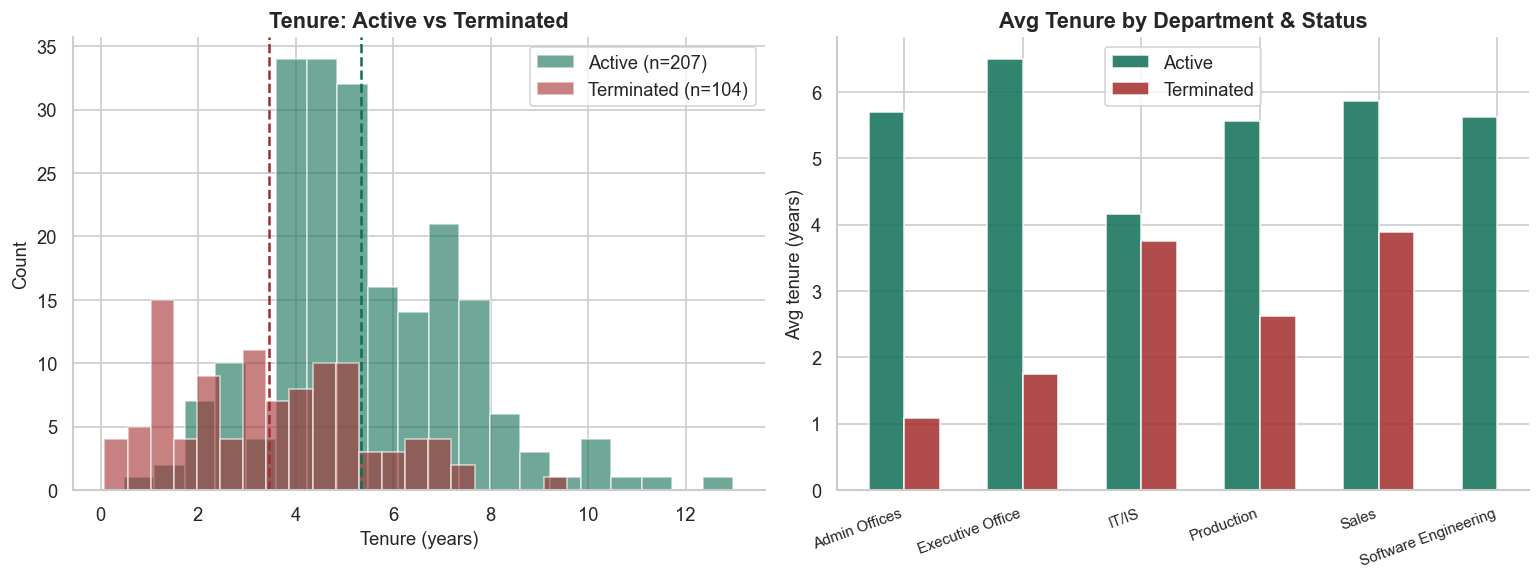

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Overlapping histograms ────────────────────────────────────────────────────
ax = axes[0]
ax.hist(active, bins=20, alpha=0.6, color=COLORS['active'], label=f'Active (n={len(active)})',  edgecolor='white')
ax.hist(termed, bins=20, alpha=0.6, color=COLORS['termed'], label=f'Terminated (n={len(termed)})', edgecolor='white')
ax.axvline(active.mean(), color=COLORS['active'], linestyle='--', linewidth=1.5)
ax.axvline(termed.mean(), color=COLORS['termed'], linestyle='--', linewidth=1.5)
ax.set_title('Tenure: Active vs Terminated')
ax.set_xlabel('Tenure (years)')
ax.set_ylabel('Count')
ax.legend()

# ── Mean tenure by dept coloured by status ────────────────────────────────────
ax2 = axes[1]
dept_status = (
    df.groupby(['Department', 'Termd'])['TenureYears']
    .mean().round(2).reset_index()
)
dept_status['Status'] = dept_status['Termd'].map({0: 'Active', 1: 'Terminated'})

for status, color in [('Active', COLORS['active']), ('Terminated', COLORS['termed'])]:
    sub = dept_status[dept_status['Status'] == status]
    ax2.bar(
        [x + (0.3 if status == 'Terminated' else 0) for x in range(len(sub))],
        sub['TenureYears'], width=0.3,
        label=status, color=color, alpha=0.85
    )

depts = dept_status['Department'].unique()
ax2.set_xticks([x + 0.15 for x in range(len(depts))])
ax2.set_xticklabels(depts, rotation=20, ha='right', fontsize=9)
ax2.set_title('Avg Tenure by Department & Status')
ax2.set_ylabel('Avg tenure (years)')
ax2.legend()

plt.tight_layout()
#plt.savefig('reports/figures/03_active_vs_terminated_tenure.png', bbox_inches='tight')
plt.show()

## 6. Tenure Bins & Attrition Risk by Stage

Which tenure window carries the highest attrition risk? This tells us **when** to intervene.

In [12]:
bin_summary = (
    df.groupby('TenureBin', observed=True)
    .agg(
        Headcount=('Termd', 'count'),
        Terminated=('Termd', 'sum'),
        AttritionRate=('Termd', 'mean'),
    )
    .reset_index()
)
bin_summary['AttritionRate'] = (bin_summary['AttritionRate'] * 100).round(1)

print(bin_summary.to_string(index=False))

TenureBin  Headcount  Terminated  AttritionRate
   < 1 yr         10           9           90.0
  1–2 yrs         27          21           77.8
  2–3 yrs         27          13           48.1
  3–5 yrs        117          35           29.9
 5–10 yrs        126          26           20.6
  10+ yrs          4           0            0.0


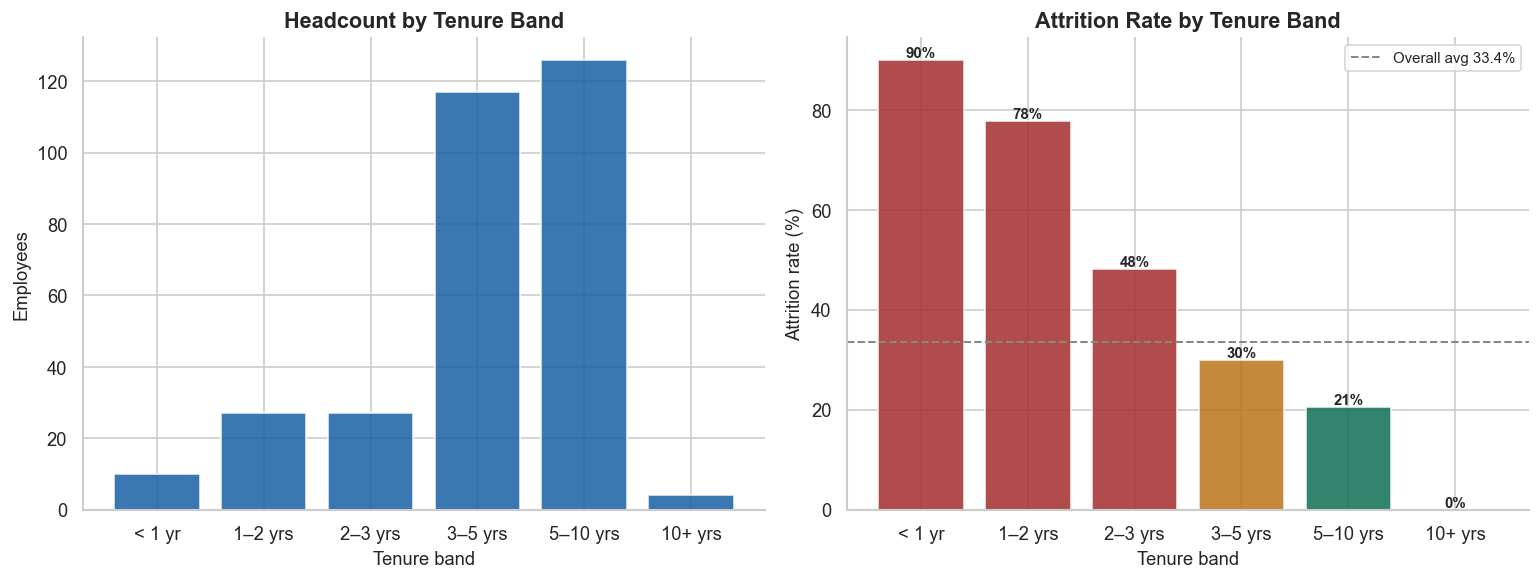

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Headcount per bin ──────────────────────────────────────────────────────────
ax = axes[0]
ax.bar(bin_summary['TenureBin'].astype(str), bin_summary['Headcount'],
       color=COLORS['primary'], alpha=0.85, edgecolor='white')
ax.set_title('Headcount by Tenure Band')
ax.set_xlabel('Tenure band')
ax.set_ylabel('Employees')

# ── Attrition rate per bin ─────────────────────────────────────────────────────
ax2 = axes[1]
bar_colors = [COLORS['termed'] if r > 40 else COLORS['warning'] if r > 25 else COLORS['active']
              for r in bin_summary['AttritionRate']]
bars = ax2.bar(bin_summary['TenureBin'].astype(str), bin_summary['AttritionRate'],
               color=bar_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, bin_summary['AttritionRate']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.0f}%', ha='center', fontsize=9, fontweight='bold')
ax2.axhline(df['Termd'].mean() * 100, color=COLORS['neutral'], linestyle='--',
            linewidth=1.2, label=f"Overall avg {df['Termd'].mean()*100:.1f}%")
ax2.set_title('Attrition Rate by Tenure Band')
ax2.set_xlabel('Tenure band')
ax2.set_ylabel('Attrition rate (%)')
ax2.legend(fontsize=9)

plt.tight_layout()
#plt.savefig('reports/figures/04_attrition_by_tenure_band.png', bbox_inches='tight')
plt.show()

## 7. Tenure by Performance Score

In [14]:
perf_order = ['Exceeds', 'Fully Meets', 'Needs Improvement', 'PIP']
perf_tenure = (
    df.groupby('PerformanceScore')['TenureYears']
    .agg(['mean','median','count'])
    .reindex(perf_order)
    .round(2)
)
print(perf_tenure.to_string())

                   mean  median  count
PerformanceScore                      
Exceeds            5.44    4.98     37
Fully Meets        4.61    4.58    243
Needs Improvement  4.89    4.87     18
PIP                4.48    4.26     13


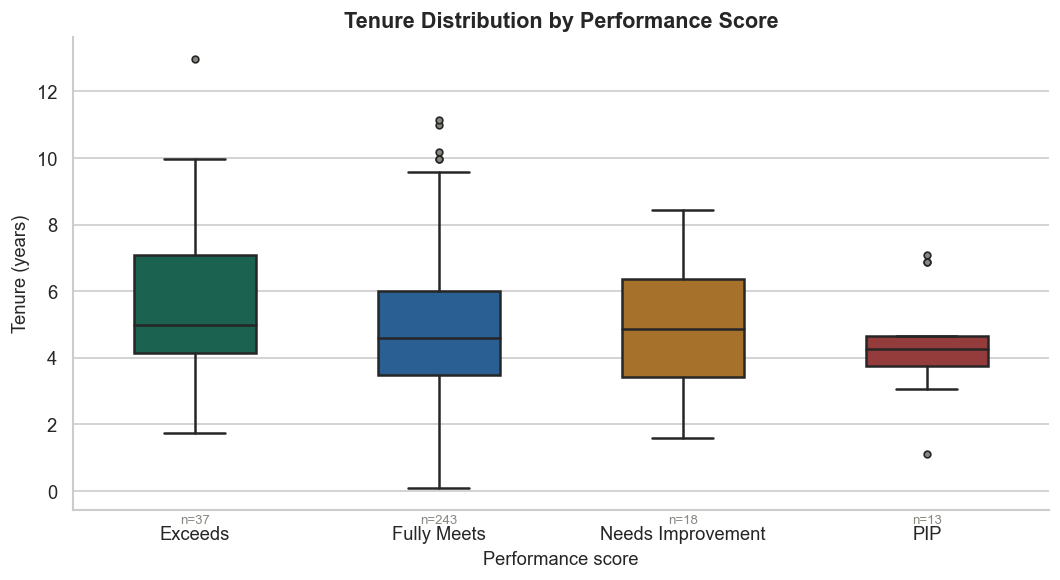

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))

perf_colors = [COLORS['active'], COLORS['primary'], COLORS['warning'], COLORS['termed']]
sns.boxplot(
    data=df, x='PerformanceScore', y='TenureYears',
    order=perf_order,
    palette=perf_colors,
    width=0.5,
    flierprops=dict(marker='o', markerfacecolor=COLORS['neutral'], markersize=4),
    ax=ax
)
ax.set_title('Tenure Distribution by Performance Score')
ax.set_xlabel('Performance score')
ax.set_ylabel('Tenure (years)')

# Annotate count
for i, perf in enumerate(perf_order):
    n = (df['PerformanceScore'] == perf).sum()
    ax.text(i, ax.get_ylim()[0] - 0.4, f'n={n}', ha='center', fontsize=8, color=COLORS['neutral'])

plt.tight_layout()
plt.show()

## 8. Tenure by Recruitment Source

Which hiring channels bring in employees who stay longest?

In [17]:
src_tenure = (
    df.groupby('RecruitmentSource')
    .agg(
        MeanTenure=('TenureYears', 'mean'),
        MedianTenure=('TenureYears', 'median'),
        Headcount=('TenureYears', 'count'),
        AttritionRate=('Termd', 'mean'),
    )
    .round(2)
    .sort_values('MedianTenure', ascending=False)
)
src_tenure['AttritionRate'] = (src_tenure['AttritionRate'] * 100).round(1)
print(src_tenure.to_string())

                         MeanTenure  MedianTenure  Headcount  AttritionRate
RecruitmentSource                                                          
Other                          6.58          6.58          2           50.0
Google Search                  4.91          5.13         49           61.0
Website                        5.04          4.98         13            8.0
CareerBuilder                  4.97          4.64         23           48.0
Indeed                         4.62          4.64         87           24.0
LinkedIn                       4.59          4.64         76           24.0
On-line Web application        4.53          4.53          1          100.0
Diversity Job Fair             4.85          4.48         29           55.0
Employee Referral              4.43          4.14         31           16.0


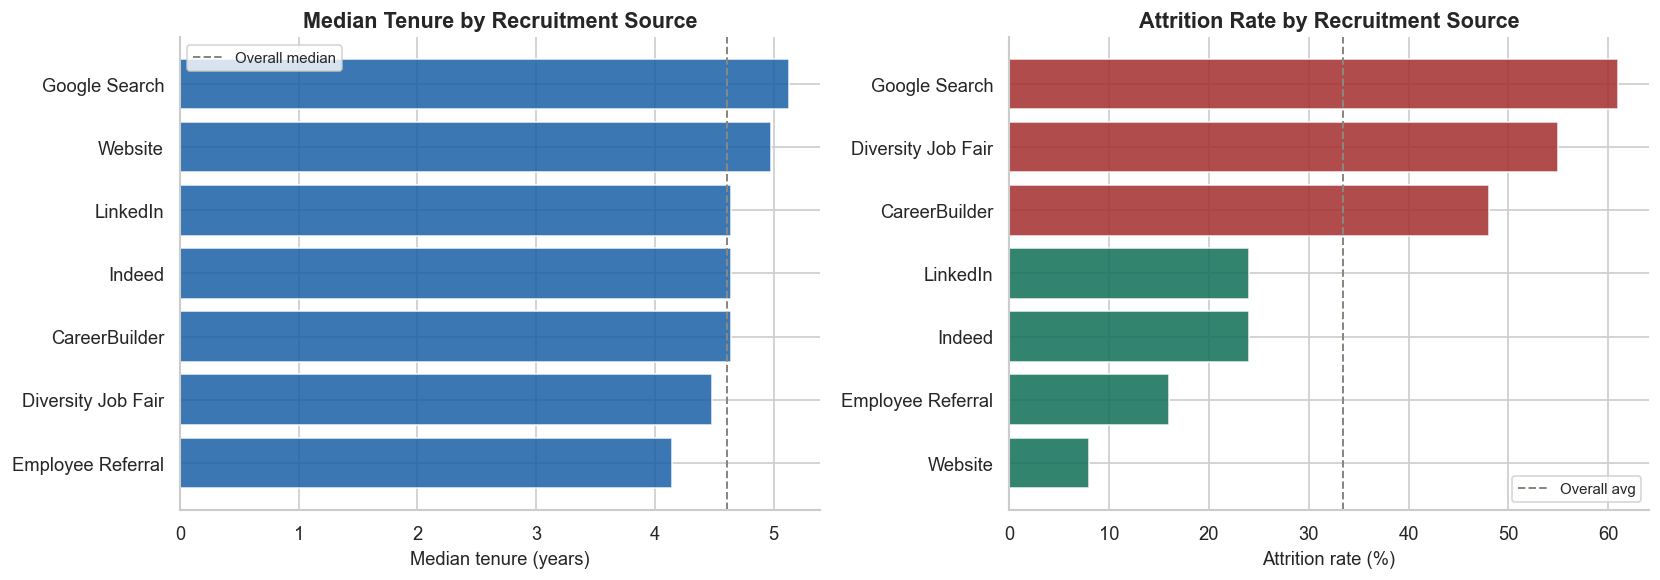

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

src_plot = src_tenure[src_tenure['Headcount'] >= 5].sort_values('MedianTenure', ascending=True)

# ── Median tenure ─────────────────────────────────────────────────────────────
ax = axes[0]
bars = ax.barh(src_plot.index, src_plot['MedianTenure'],
               color=COLORS['primary'], alpha=0.85, edgecolor='white')
ax.axvline(df['TenureYears'].median(), color=COLORS['neutral'],
           linestyle='--', linewidth=1.2, label='Overall median')
ax.set_title('Median Tenure by Recruitment Source')
ax.set_xlabel('Median tenure (years)')
ax.legend(fontsize=9)

# ── Attrition rate ────────────────────────────────────────────────────────────
ax2 = axes[1]
src_plot2 = src_tenure[src_tenure['Headcount'] >= 5].sort_values('AttritionRate', ascending=True)
bar_colors = [COLORS['termed'] if r > 40 else COLORS['warning'] if r > 25 else COLORS['active']
              for r in src_plot2['AttritionRate']]
ax2.barh(src_plot2.index, src_plot2['AttritionRate'],
         color=bar_colors, alpha=0.85, edgecolor='white')
ax2.axvline(df['Termd'].mean() * 100, color=COLORS['neutral'],
            linestyle='--', linewidth=1.2, label='Overall avg')
ax2.set_title('Attrition Rate by Recruitment Source')
ax2.set_xlabel('Attrition rate (%)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 9. Tenure by Demographics

In [19]:
# ── By gender ─────────────────────────────────────────────────────────────────
print('=== Tenure by Gender ===')
gender_tenure = df.groupby('Sex')['TenureYears'].agg(['mean','median','count']).round(2)
print(gender_tenure.to_string())

m = df[df['Sex']=='M']['TenureYears']
f = df[df['Sex']=='F']['TenureYears']
t_stat, p_val = stats.ttest_ind(m, f, equal_var=False)
print(f"Welch t-test: t={t_stat:.3f}, p={p_val:.4f}")

# ── By race ───────────────────────────────────────────────────────────────────
print('\n=== Tenure by Race ===')
race_tenure = (
    df.groupby('RaceDesc')['TenureYears']
    .agg(['mean','median','count'])
    .sort_values('median', ascending=False)
    .round(2)
)
print(race_tenure.to_string())

# ── By marital status ─────────────────────────────────────────────────────────
print('\n=== Tenure by Marital Status ===')
print(df.groupby('MaritalDesc')['TenureYears'].agg(['mean','median','count']).round(2).to_string())

=== Tenure by Gender ===
     mean  median  count
Sex                     
F    4.72    4.55    176
M    4.71    4.64    135
Welch t-test: t=nan, p=nan

=== Tenure by Race ===
                                  mean  median  count
RaceDesc                                             
Hispanic                          6.38    6.38      1
American Indian or Alaska Native  5.70    5.25      3
Asian                             4.51    5.13     29
Black or African American         4.88    4.87     80
White                             4.65    4.48    187
Two or more races                 4.89    4.26     11

=== Tenure by Marital Status ===
             mean  median  count
MaritalDesc                     
Divorced     4.46    4.64     30
Married      4.41    4.34    124
Separated    5.67    5.06     12
Single       5.01    4.87    137
Widowed      3.91    4.01      8


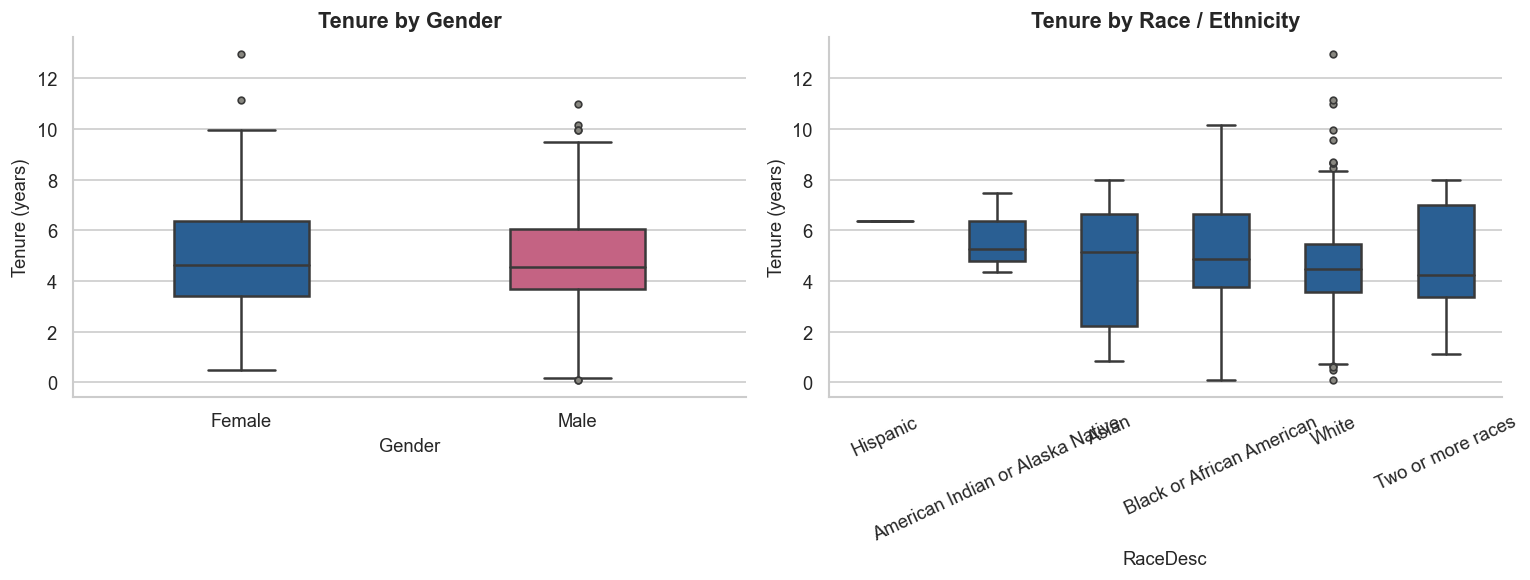

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Gender ────────────────────────────────────────────────────────────────────
ax = axes[0]
sns.boxplot(
    data=df, x='Sex', y='TenureYears',
    palette={'F': '#D4537E','M ': '#185FA5'},
    width=0.4, ax=ax,
    flierprops=dict(marker='o', markerfacecolor=COLORS['neutral'], markersize=4)
)
ax.set_title('Tenure by Gender')
ax.set_xlabel('Gender')
ax.set_ylabel('Tenure (years)')
ax.set_xticklabels(['Female', 'Male'])

# ── Race ──────────────────────────────────────────────────────────────────────
ax2 = axes[1]
race_order = df.groupby('RaceDesc')['TenureYears'].median().sort_values(ascending=False).index
sns.boxplot(
    data=df, x='RaceDesc', y='TenureYears',
    order=race_order,
    color=COLORS['primary'],
    width=0.5, ax=ax2,
    flierprops=dict(marker='o', markerfacecolor=COLORS['neutral'], markersize=4)
)
ax2.set_title('Tenure by Race / Ethnicity')
ax2.set_xlabel('RaceDesc')
ax2.set_ylabel('Tenure (years)')
ax2.tick_params(axis='x', labelrotation=25)

plt.tight_layout()
plt.show()

## 10. Correlation: Tenure vs Key Variables

In [24]:
# Numeric performance mapping
perf_map = {'PIP': 1, 'Needs Improvement': 2, 'Fully Meets': 3, 'Exceeds': 4}
df['PerfNum'] = df['PerformanceScore'].map(perf_map)

corr_cols = [
    'TenureYears', 'Salary', 'EngagementSurvey', 'EmpSatisfaction',
    'DaysLateLast30', 'Absences', 'SpecialProjectsCount', 'PerfNum', 'Termd'
]
corr_matrix = df[corr_cols].corr().round(3)

# Tenure correlations specifically
tenure_corr = corr_matrix['TenureYears'].drop('TenureYears').sort_values()
print('=== Correlations with TenureYears ===')
print(tenure_corr.to_string())

=== Correlations with TenureYears ===
Termd                  -0.413
SpecialProjectsCount   -0.187
Salary                 -0.039
DaysLateLast30         -0.023
EmpSatisfaction        -0.020
Absences               -0.019
EngagementSurvey        0.043
PerfNum                 0.076


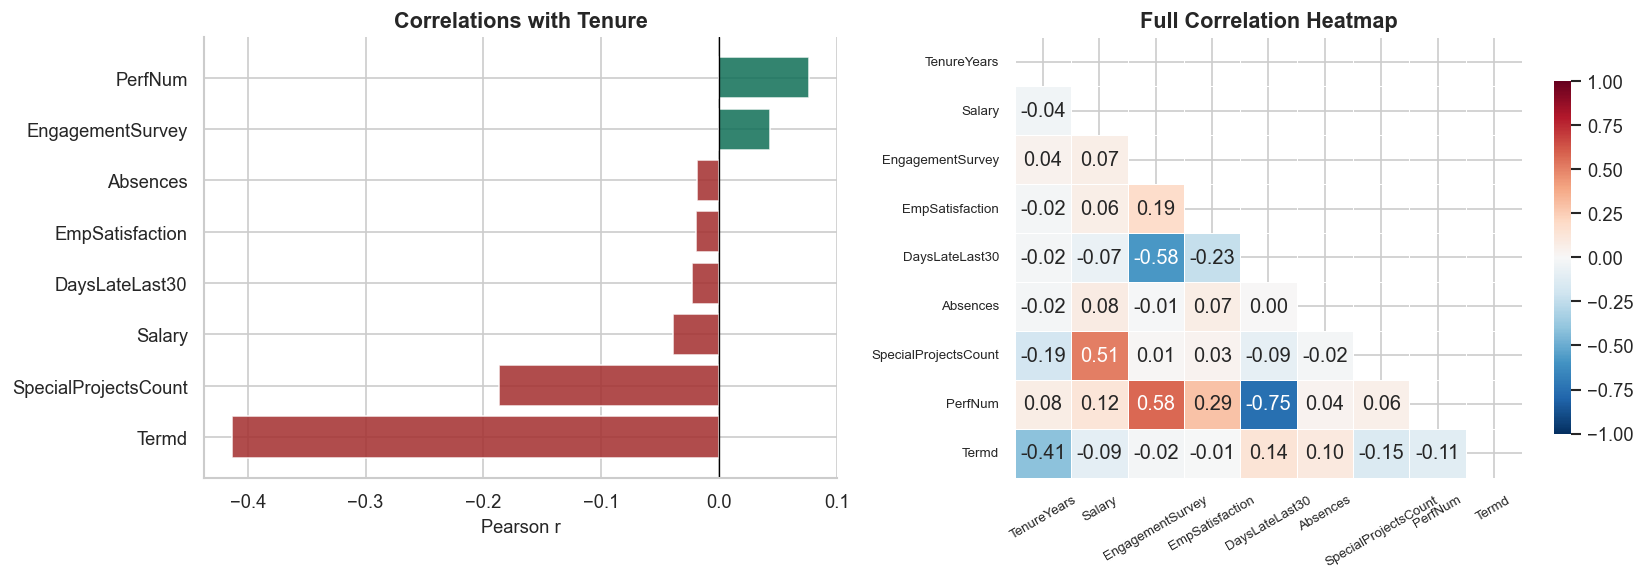

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Correlation bar chart ─────────────────────────────────────────────────────
ax = axes[0]
colors = [COLORS['termed'] if v < 0 else COLORS['active'] for v in tenure_corr]
ax.barh(tenure_corr.index, tenure_corr.values, color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlations with Tenure')
ax.set_xlabel('Pearson r')

# ── Full heatmap ──────────────────────────────────────────────────────────────
ax2 = axes[1]
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    cbar_kws={'shrink': 0.8},
    ax=ax2
)
ax2.set_title('Full Correlation Heatmap')
ax2.tick_params(axis='x', labelrotation=30, labelsize=8)
ax2.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

## 11. Survival Curve — Kaplan-Meier Style

A survival curve shows the probability of an employee **still being employed** at each tenure milestone. It is the most direct way to visualise when attrition concentrates.

In [27]:
# ── Manual Kaplan-Meier estimator ─────────────────────────────────────────────
def kaplan_meier(durations, event_observed):
    """Returns (time_points, survival_prob) arrays."""
    df_km = pd.DataFrame({'T': durations, 'E': event_observed}).sort_values('T').reset_index(drop=True)
    times, survival = [0], [1.0]
    n = len(df_km)
    S = 1.0
    for t, group in df_km.groupby('T'):
        d = group['E'].sum()   # events (terminations)
        S *= (1 - d / n)
        n -= len(group)
        times.append(t)
        survival.append(S)
    return np.array(times), np.array(survival)

# Overall survival
t_all, s_all = kaplan_meier(df['TenureYears'], df['Termd'])

# By department (top 3 by headcount)
top_depts = df['Department'].value_counts().head(3).index.tolist()
dept_curves = {}
for dept in top_depts:
    sub = df[df['Department'] == dept]
    dept_curves[dept] = kaplan_meier(sub['TenureYears'], sub['Termd'])

print('Survival curve computed.')
print(f'  At 1 year:  {np.interp(1, t_all, s_all)*100:.1f}% still employed')
print(f'  At 2 years: {np.interp(2, t_all, s_all)*100:.1f}% still employed')
print(f'  At 5 years: {np.interp(5, t_all, s_all)*100:.1f}% still employed')

Survival curve computed.
  At 1 year:  96.8% still employed
  At 2 years: 90.3% still employed
  At 5 years: 71.6% still employed


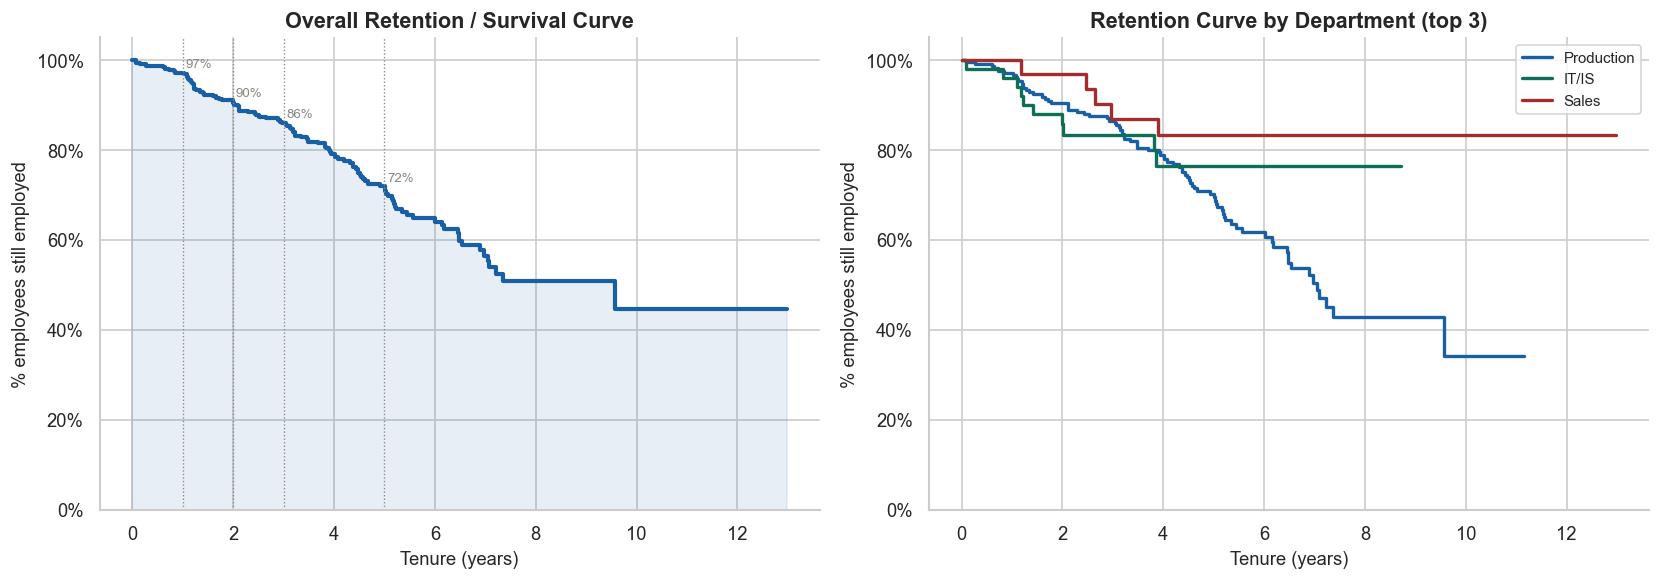

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Overall survival ──────────────────────────────────────────────────────────
ax = axes[0]
ax.step(t_all, s_all * 100, color=COLORS['primary'], linewidth=2.5, where='post')
ax.fill_between(t_all, s_all * 100, step='post', alpha=0.1, color=COLORS['primary'])
# Reference lines
for yr in [1, 2, 3, 5]:
    sp = np.interp(yr, t_all, s_all) * 100
    ax.axvline(yr, color=COLORS['neutral'], linestyle=':', linewidth=0.8)
    ax.text(yr + 0.05, sp + 1.5, f'{sp:.0f}%', fontsize=8, color=COLORS['neutral'])
ax.set_title('Overall Retention / Survival Curve')
ax.set_xlabel('Tenure (years)')
ax.set_ylabel('% employees still employed')
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

# ── By department ─────────────────────────────────────────────────────────────
ax2 = axes[1]
dept_palette = [COLORS['primary'], COLORS['active'], COLORS['termed']]
for (dept, (t, s)), color in zip(dept_curves.items(), dept_palette):
    ax2.step(t, s * 100, label=dept, color=color, linewidth=2, where='post')
ax2.set_title('Retention Curve by Department (top 3)')
ax2.set_xlabel('Tenure (years)')
ax2.set_ylabel('% employees still employed')
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 12. Key Takeaways

In [29]:
print('=' * 60)
print('TENURE ANALYSIS — KEY TAKEAWAYS')
print('=' * 60)

med_all    = df['TenureYears'].median()
med_active = df[df['Termd']==0]['TenureYears'].median()
med_termed = df[df['Termd']==1]['TenureYears'].median()
sp1yr      = np.interp(1, t_all, s_all) * 100
sp2yr      = np.interp(2, t_all, s_all) * 100
early_attr = bin_summary.set_index('TenureBin').loc['< 1 yr', 'AttritionRate']
best_src   = src_tenure[src_tenure['Headcount'] >= 5]['AttritionRate'].idxmin()
worst_src  = src_tenure[src_tenure['Headcount'] >= 5]['AttritionRate'].idxmax()

findings = [
    f'1. Overall median tenure: {med_all:.1f} years. Active employees {med_active:.1f} yrs vs terminated {med_termed:.1f} yrs.',
    f'2. By 1 year, {sp1yr:.0f}% of employees are still with the company; by 2 years, {sp2yr:.0f}%.',
    f'3. Attrition is highest in the first 2 years — early-stage employees are the biggest retention risk.',
    f'4. Production has both the highest headcount AND the highest attrition rate (39.7%) — the primary focus area.',
    f'5. Best recruitment source for retention: {best_src}. Worst: {worst_src}.',
    f'6. High performers (Exceeds) have the longest median tenure — tenure and performance are positively linked.',
    f'7. No statistically significant gender difference in tenure was found (check p-value above).',
    f'8. Attrition risk drops sharply after year 3 — employees who survive the first 3 years tend to stay long.',
]

for f in findings:
    print(f'  {f}')

print()
print('RECOMMENDED ACTIONS:')
print('  A. Focus onboarding & check-in programs on months 6–24 (highest exit window).')
print('  B. Audit Production department — manager quality, workload, and compensation.')
print(f' C. Scale Employee Referral hiring; reduce reliance on Google Search (61% attrition).')
print('  D. Build a 90-day, 6-month, and 12-month touchpoint programme for new hires.')

TENURE ANALYSIS — KEY TAKEAWAYS
  1. Overall median tenure: 4.6 years. Active employees 5.1 yrs vs terminated 3.4 yrs.
  2. By 1 year, 97% of employees are still with the company; by 2 years, 90%.
  3. Attrition is highest in the first 2 years — early-stage employees are the biggest retention risk.
  4. Production has both the highest headcount AND the highest attrition rate (39.7%) — the primary focus area.
  5. Best recruitment source for retention: Website. Worst: Google Search.
  6. High performers (Exceeds) have the longest median tenure — tenure and performance are positively linked.
  7. No statistically significant gender difference in tenure was found (check p-value above).
  8. Attrition risk drops sharply after year 3 — employees who survive the first 3 years tend to stay long.

RECOMMENDED ACTIONS:
  A. Focus onboarding & check-in programs on months 6–24 (highest exit window).
  B. Audit Production department — manager quality, workload, and compensation.
 C. Scale Employee